# Segmentación de hogares por consumo eléctrico

## Proyecto Final de Machine Learning

**Objetivo de esta libreta:** construir y evaluar modelos de clustering para segmentar hogares según su patrón de consumo eléctrico residencial.

El propósito de esta libreta es identificar perfiles de hogares que puedan traducirse en decisiones de negocio para una empresa eléctrica, por ejemplo: campañas de eficiencia energética, monitoreo de hogares atípicos o estrategias diferenciadas para hogares de mayor consumo.

### Pregunta de negocio

> ¿Qué grupos de hogares pueden identificarse a partir de su comportamiento de consumo eléctrico y qué decisiones puede tomar una empresa eléctrica con base en esos grupos?

### Alcance de esta libreta

1. Carga y validación del perfil agregado por hogar.
2. Tratamiento de valores atípicos relevantes.
3. Escalado de variables para clustering.
4. Evaluación de K-Means sin PCA.
5. Evaluación de K-Means con PCA.
6. Evaluación exploratoria de DBSCAN.
7. Comparación de modelos y conclusión parcial.

### Estado actual del análisis

Hasta este punto, el análisis muestra que:

- **K-Means + PCA** genera una segmentación principal simple e interpretable de 2 grupos.
- **DBSCAN + PCA** obtiene métricas atractivas, pero su distribución concentra casi todos los hogares en un solo cluster y genera microclusters, por lo que se considera más útil como técnica complementaria para detectar hogares atípicos que como modelo principal de segmentación.

# 1. Importación de librerías y configuración general

Se centralizan todas las importaciones en una sola celda para evitar repeticiones. También se crean carpetas de salida para guardar gráficas y archivos generados durante el análisis.

In [26]:
# Manipulación y cálculo
import os
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt

# Preprocesamiento y reducción de dimensión
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Modelos de clustering
from sklearn.cluster import KMeans, DBSCAN

# Métricas de evaluación de clustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# Configuración general
RANDOM_STATE = 42
DATA_PATH = "./data/smart_meters_hogar_perfil.csv"
OUTPUT_DIR = "./output"
IMAGES_DIR = os.path.join(OUTPUT_DIR, "images")

os.makedirs(IMAGES_DIR, exist_ok=True)
pd.set_option("display.max_columns", None)

# 2. Carga del dataset y exploración inicial

El archivo utilizado en esta libreta corresponde a un perfil agregado por hogar. Cada fila representa un hogar (`LCLid`) y contiene variables descriptivas de consumo eléctrico, estacionalidad, consumo entre semana/fin de semana, tarifa y clasificación ACORN.

In [27]:
# Carga del dataset de perfiles de hogar
df_profile = pd.read_csv(DATA_PATH)

print("Shape del dataset:", df_profile.shape)
display(df_profile.head())

Shape del dataset: (5384, 15)


,LCLid,consumo_total,consumo_medio,consumo_std,consumo_max,consumo_invierno,consumo_verano,consumo_finde,consumo_semana,ratio_invierno_verano,dias_registrados,stdorToU,Acorn_grouped,tarifa_enc,acorn_enc
0,MAC000002,6022.602001,12.093578,4.517378,39.284,13.203778,9.141011,12.863732,11.786382,1.444455,498,Std,Affluent,0,3
1,MAC000003,13949.956003,19.031318,11.641836,50.759,27.928126,12.229174,18.791663,19.126267,2.283729,733,Std,Adversity,0,2
2,MAC000004,1109.965000,1.694603,0.431671,7.354,1.837633,1.522543,1.738516,1.677188,1.206949,655,Std,Affluent,0,3
3,MAC000005,2878.618000,4.561994,1.473369,16.708,5.537317,3.676062,4.577333,4.555871,1.506317,631,ToU,Affluent,1,3
4,MAC000006,2143.429000,2.842744,0.882945,6.636,2.985642,2.462321,2.727290,2.888498,1.212531,754,Std,Adversity,0,2


In [28]:
# Revisión de estructura, tipos de datos y valores faltantes
print("Información general del dataset:")
df_profile.info()

print("\nValores faltantes por columna:")
display(df_profile.isna().sum())

print("\nRegistros duplicados:", df_profile.duplicated().sum())

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5384 entries, 0 to 5383
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   LCLid                  5384 non-null   object 
 1   consumo_total          5384 non-null   float64
 2   consumo_medio          5384 non-null   float64
 3   consumo_std            5384 non-null   float64
 4   consumo_max            5384 non-null   float64
 5   consumo_invierno       5384 non-null   float64
 6   consumo_verano         5384 non-null   float64
 7   consumo_finde          5384 non-null   float64
 8   consumo_semana         5384 non-null   float64
 9   ratio_invierno_verano  5384 non-null   float64
 10  dias_registrados       5384 non-null   int64  
 11  stdorToU               5384 non-null   object 
 12  Acorn_grouped          5384 non-null   object 
 13  tarifa_enc             5384 non-null   int64  
 14  acorn_enc              

LCLid                    0
consumo_total            0
consumo_medio            0
consumo_std              0
consumo_max              0
consumo_invierno         0
consumo_verano           0
consumo_finde            0
consumo_semana           0
ratio_invierno_verano    0
dias_registrados         0
stdorToU                 0
Acorn_grouped            0
tarifa_enc               0
acorn_enc                0
dtype: int64


Registros duplicados: 0


In [29]:
# Estadísticas descriptivas iniciales
display(df_profile.describe().T)

,count,mean,std,min,25%,50%,75%,max
consumo_total,5384.0,6448.877363,4718.147142,0.0,3385.013000,5288.045499,8116.448250,65077.588003
consumo_medio,5384.0,10.178303,7.327760,0.0,5.380213,8.335489,12.813572,101.366960
consumo_std,5384.0,3.872435,3.884581,0.0,1.663583,2.751953,4.492990,61.806950
consumo_max,5384.0,27.060777,22.128664,0.0,13.388750,21.339500,33.681000,332.556001
consumo_invierno,5384.0,12.030863,9.832609,0.0,5.981807,9.429597,14.812013,111.226833
consumo_verano,5384.0,8.235860,5.500497,0.0,4.577072,7.050611,10.409243,87.281598
consumo_finde,5384.0,10.521794,7.415615,0.0,5.531405,8.687031,13.304658,96.844533
consumo_semana,5384.0,10.041569,7.334408,0.0,5.293714,8.215018,12.562853,103.156267
ratio_invierno_verano,5384.0,140.661771,8238.337430,0.0,1.111482,1.277518,1.531560,582061.108889
dias_registrados,5384.0,636.415490,88.032609,358.0,596.000000,646.000000,679.000000,822.000000


# 3. Revisión de valores problemáticos

Antes de entrenar modelos de clustering, se revisan casos que pueden distorsionar los resultados:

- Hogares con consumo total igual a cero.
- Hogares con consumo de verano igual a cero.
- Valores extremos en `ratio_invierno_verano`.

Este paso es importante porque K-Means y PCA son sensibles a magnitudes extremas.

In [30]:
# Hogares sin consumo total registrado
hogares_consumo_cero = df_profile[df_profile["consumo_total"] == 0]

print("Hogares con consumo_total = 0:", hogares_consumo_cero.shape[0])
display(hogares_consumo_cero.head())

Hogares con consumo_total = 0: 1


,LCLid,consumo_total,consumo_medio,consumo_std,consumo_max,consumo_invierno,consumo_verano,consumo_finde,consumo_semana,ratio_invierno_verano,dias_registrados,stdorToU,Acorn_grouped,tarifa_enc,acorn_enc
3921,MAC004067,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,645,Std,ACORN-U,0,1


In [31]:
# Hogares con consumo de verano igual a cero
hogares_verano_cero = df_profile[df_profile["consumo_verano"] == 0]

print("Hogares con consumo_verano = 0:", hogares_verano_cero.shape[0])
display(
    hogares_verano_cero[
        [
            "LCLid",
            "consumo_total",
            "consumo_medio",
            "consumo_invierno",
            "consumo_verano",
            "ratio_invierno_verano",
            "dias_registrados"
        ]
    ].head(10)
)

Hogares con consumo_verano = 0: 3


,LCLid,consumo_total,consumo_medio,consumo_invierno,consumo_verano,ratio_invierno_verano,dias_registrados
2497,MAC002594,1.283000,0.002167,0.000522,0.0,522.222222,592
3490,MAC003627,760.431999,1.523912,0.582061,0.0,582061.108889,499
3921,MAC004067,0.000000,0.000000,0.000000,0.0,0.000000,645


In [32]:
# Percentiles del ratio invierno/verano para identificar valores extremos
ratio_percentiles = df_profile["ratio_invierno_verano"].describe(
    percentiles=[0.90, 0.95, 0.97, 0.99]
)

display(ratio_percentiles)

count      5384.000000
mean        140.661771
std        8238.337430
min           0.000000
50%           1.277518
90%           2.087758
95%           2.818759
97%           3.539556
99%           5.288940
max      582061.108889
Name: ratio_invierno_verano, dtype: float64

# 4. Tratamiento de valores atípicos

Se realizan dos ajustes:

1. Se elimina el hogar con `consumo_total = 0`, ya que no representa un patrón real de consumo.
2. Se crea `ratio_invierno_verano_clip`, limitando `ratio_invierno_verano` al percentil 99 para evitar que valores extremos dominen la segmentación.

No se elimina directamente a todos los hogares con `consumo_verano = 0`, porque algunos pueden representar casos reales; el problema principal era el cociente extremo.

In [33]:
# Copia de trabajo para clustering
hogar_cluster = df_profile.copy()

# Eliminar hogares sin consumo total
hogar_cluster = hogar_cluster[hogar_cluster["consumo_total"] > 0].copy()

# Controlar valores extremos del ratio invierno/verano usando percentil 99
limite_ratio = hogar_cluster["ratio_invierno_verano"].quantile(0.99)
hogar_cluster["ratio_invierno_verano_clip"] = hogar_cluster["ratio_invierno_verano"].clip(
    upper=limite_ratio
)

print("Límite usado para ratio_invierno_verano_clip:", limite_ratio)
print("Shape después de limpieza:", hogar_cluster.shape)
print("Hogares únicos:", hogar_cluster["LCLid"].nunique())

display(
    hogar_cluster[
        [
            "consumo_total",
            "consumo_medio",
            "consumo_invierno",
            "consumo_verano",
            "ratio_invierno_verano",
            "ratio_invierno_verano_clip"
        ]
    ].describe().T
)

Límite usado para ratio_invierno_verano_clip: 5.28946411378567
Shape después de limpieza: (5383, 16)
Hogares únicos: 5383


,count,mean,std,min,25%,50%,75%,max
consumo_total,5383.0,6450.075371,4717.766415,1.283000,3387.169500,5288.127999,8116.860500,65077.588003
consumo_medio,5383.0,10.180193,7.327127,0.002167,5.383759,8.336881,12.815045,101.366960
consumo_invierno,5383.0,12.033098,9.832154,0.000317,5.984750,9.438400,14.814308,111.226833
consumo_verano,5383.0,8.237390,5.499862,0.000000,4.578310,7.051136,10.409481,87.281598
ratio_invierno_verano,5383.0,140.687902,8239.102531,0.000247,1.111542,1.277551,1.531663,582061.108889
ratio_invierno_verano_clip,5383.0,1.470867,0.716481,0.000247,1.111542,1.277551,1.531663,5.289464


# 5. Selección de variables para clustering

Se seleccionan variables numéricas que describen magnitud, variabilidad, estacionalidad y cobertura de registros.

Las variables categóricas como `stdorToU` y `Acorn_grouped` no se usan para entrenar el clustering, porque el objetivo es agrupar hogares por comportamiento de consumo. Posteriormente pueden usarse para interpretar los clusters.

In [34]:
FEATURES_CLUSTERING = [
    "consumo_total",
    "consumo_medio",
    "consumo_std",
    "consumo_max",
    "consumo_invierno",
    "consumo_verano",
    "consumo_finde",
    "consumo_semana",
    "ratio_invierno_verano_clip",
    "dias_registrados"
]

print("Variables seleccionadas para clustering:")
for feature in FEATURES_CLUSTERING:
    print("-", feature)

Variables seleccionadas para clustering:
- consumo_total
- consumo_medio
- consumo_std
- consumo_max
- consumo_invierno
- consumo_verano
- consumo_finde
- consumo_semana
- ratio_invierno_verano_clip
- dias_registrados


In [35]:
# Validación final de variables seleccionadas
print("Valores faltantes en variables de clustering:")
display(hogar_cluster[FEATURES_CLUSTERING].isnull().sum())

print("\nEstadísticas descriptivas de variables de clustering:")
display(hogar_cluster[FEATURES_CLUSTERING].describe().T)

Valores faltantes en variables de clustering:


consumo_total                 0
consumo_medio                 0
consumo_std                   0
consumo_max                   0
consumo_invierno              0
consumo_verano                0
consumo_finde                 0
consumo_semana                0
ratio_invierno_verano_clip    0
dias_registrados              0
dtype: int64


Estadísticas descriptivas de variables de clustering:


,count,mean,std,min,25%,50%,75%,max
consumo_total,5383.0,6450.075371,4717.766415,1.283000,3387.169500,5288.127999,8116.860500,65077.588003
consumo_medio,5383.0,10.180193,7.327127,0.002167,5.383759,8.336881,12.815045,101.366960
consumo_std,5383.0,3.873154,3.884583,0.036446,1.664142,2.752383,4.493023,61.806950
consumo_max,5383.0,27.065804,22.127645,0.854000,13.391000,21.341000,33.681000,332.556001
consumo_invierno,5383.0,12.033098,9.832154,0.000317,5.984750,9.438400,14.814308,111.226833
consumo_verano,5383.0,8.237390,5.499862,0.000000,4.578310,7.051136,10.409481,87.281598
consumo_finde,5383.0,10.523749,7.414917,0.000893,5.531880,8.687509,13.304714,96.844533
consumo_semana,5383.0,10.043434,7.333812,0.002672,5.294681,8.220862,12.564778,103.156267
ratio_invierno_verano_clip,5383.0,1.470867,0.716481,0.000247,1.111542,1.277551,1.531663,5.289464
dias_registrados,5383.0,636.413896,88.040709,358.000000,596.000000,646.000000,679.000000,822.000000


# 6. Estandarización de variables

Los algoritmos de clustering basados en distancia, como K-Means y DBSCAN, son sensibles a la escala de las variables. Por ello, se aplica `StandardScaler` para que todas las variables tengan media cercana a 0 y desviación estándar cercana a 1.

In [36]:
# Preparación de matriz de variables
X_cluster = hogar_cluster[FEATURES_CLUSTERING].copy()

# Reemplazo preventivo de infinitos o nulos, en caso de cambios futuros en el dataset
X_cluster = X_cluster.replace([np.inf, -np.inf], np.nan)
X_cluster = X_cluster.fillna(X_cluster.median(numeric_only=True))

# Escalado
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# Validación del escalado
X_scaled_df = pd.DataFrame(X_cluster_scaled, columns=FEATURES_CLUSTERING)

print("Shape X_cluster:", X_cluster.shape)
print("Shape X_cluster_scaled:", X_cluster_scaled.shape)
print("NaN en X_cluster_scaled:", np.isnan(X_cluster_scaled).sum())
print("Inf en X_cluster_scaled:", np.isinf(X_cluster_scaled).sum())

display(X_scaled_df.describe().T[["mean", "std", "min", "max"]])

Shape X_cluster: (5383, 10)
Shape X_cluster_scaled: (5383, 10)
NaN en X_cluster_scaled: 0
Inf en X_cluster_scaled: 0


,mean,std,min,max
consumo_total,1.399174e-16,1.000093,-1.367043,12.428118
consumo_medio,9.503823e-17,1.000093,-1.389217,12.446248
consumo_std,2.111961e-17,1.000093,-0.987767,14.915159
consumo_max,-8.975832e-17,1.000093,-1.184683,13.807099
consumo_invierno,-2.111961e-17,1.000093,-1.223933,10.089645
consumo_verano,4.487916e-17,1.000093,-1.497884,14.373370
consumo_finde,-1.319975e-16,1.000093,-1.419279,11.642585
consumo_semana,-1.583970e-17,1.000093,-1.369233,12.697556
ratio_invierno_verano_clip,-5.279901e-17,1.000093,-2.052749,5.330151
dias_registrados,-4.646313e-16,1.000093,-3.162625,2.108154


# 7. Funciones auxiliares de evaluación

Se define una función reutilizable para evaluar resultados de clustering mediante métricas estándar:

- **Silhouette Score:** mayor es mejor.
- **Davies-Bouldin Index:** menor es mejor.
- **Calinski-Harabasz Score:** mayor es mejor.

En DBSCAN, los puntos marcados como `-1` se consideran ruido. Para calcular métricas, se excluye el ruido cuando existen al menos dos clusters reales.

In [37]:
def evaluate_clustering(X, labels):
    '''Calcula métricas de clustering excluyendo ruido si existe la etiqueta -1.'''
    labels = np.asarray(labels)
    mask = labels != -1
    unique_clusters = set(labels[mask])

    if len(unique_clusters) < 2:
        return {
            "Silhouette": np.nan,
            "Davies_Bouldin": np.nan,
            "Calinski_Harabasz": np.nan
        }

    return {
        "Silhouette": silhouette_score(X[mask], labels[mask]),
        "Davies_Bouldin": davies_bouldin_score(X[mask], labels[mask]),
        "Calinski_Harabasz": calinski_harabasz_score(X[mask], labels[mask])
    }

# 8. Evaluación de K-Means sin PCA

Se evalúa K-Means con valores de `K` de 2 a 10. Esta evaluación sirve como línea base para comparar si PCA mejora la separación entre clusters.

In [38]:
resultados_kmeans = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_cluster_scaled)
    metrics = evaluate_clustering(X_cluster_scaled, labels)

    resultados_kmeans.append({
        "K": k,
        "Inertia": kmeans.inertia_,
        **metrics
    })

df_resultados_kmeans = pd.DataFrame(resultados_kmeans)
display(df_resultados_kmeans)

/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github

,K,Inertia,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,2,31139.337969,0.538076,0.928353,3921.035589
1,3,23267.391602,0.392546,1.016980,3533.419054
2,4,19916.493541,0.349280,1.073964,3053.094438
3,5,17472.664634,0.346012,1.052979,2797.652128
4,6,15538.079243,0.313971,1.064490,2650.207335
5,7,13762.636349,0.295697,1.057488,2608.540756
6,8,12820.759961,0.284122,1.100699,2456.114035
7,9,12089.596479,0.271652,1.125610,2319.287118
8,10,11285.510403,0.255031,1.147330,2250.597246


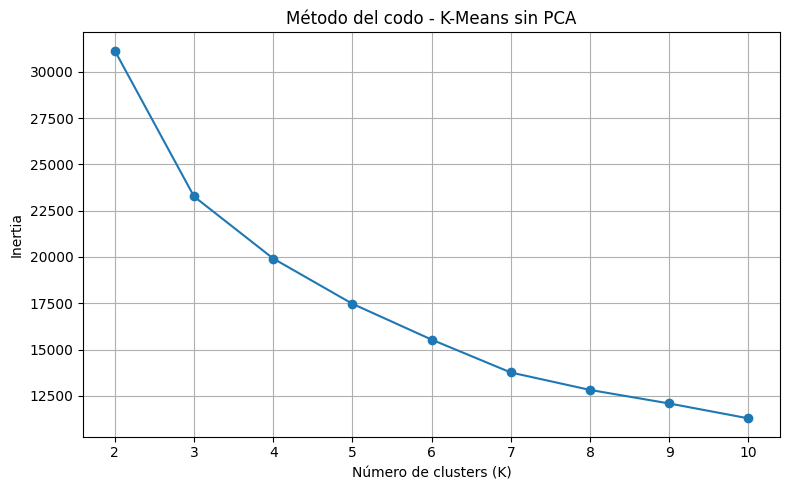

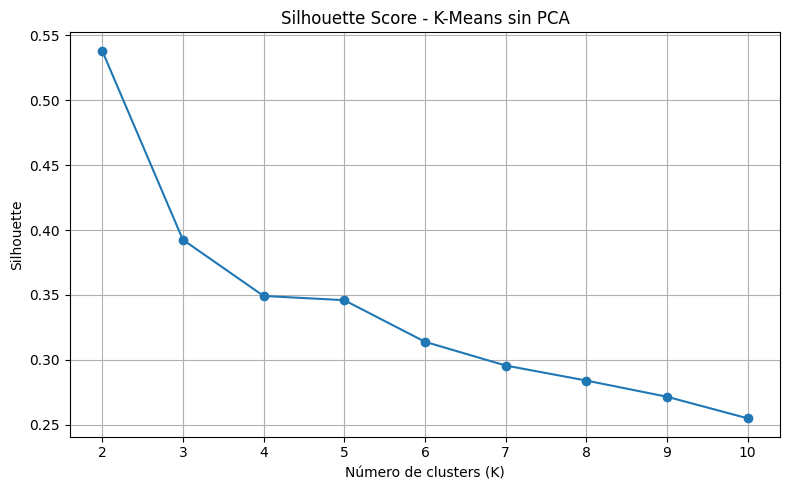

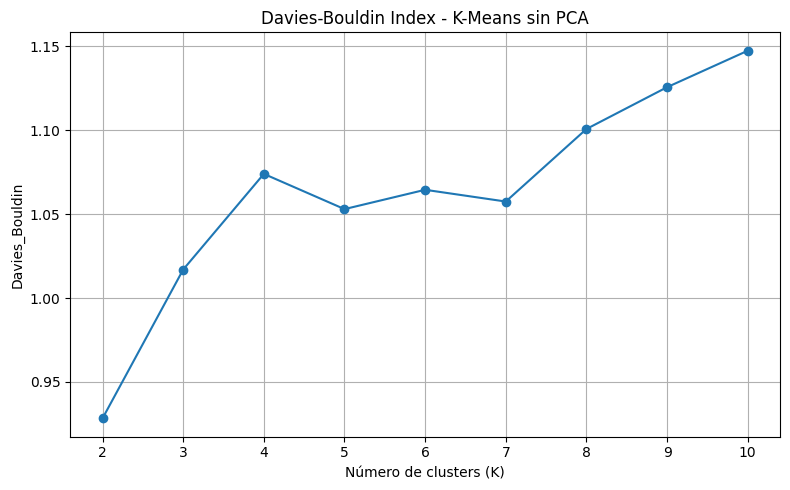

In [39]:
# Gráficas de evaluación de K-Means sin PCA
figures_kmeans = {
    "Inertia": "Método del codo - K-Means sin PCA",
    "Silhouette": "Silhouette Score - K-Means sin PCA",
    "Davies_Bouldin": "Davies-Bouldin Index - K-Means sin PCA"
}

for metric, title in figures_kmeans.items():
    plt.figure(figsize=(8, 5))
    plt.plot(df_resultados_kmeans["K"], df_resultados_kmeans[metric], marker="o")
    plt.title(title)
    plt.xlabel("Número de clusters (K)")
    plt.ylabel(metric)
    plt.xticks(df_resultados_kmeans["K"])
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(IMAGES_DIR, f"kmeans_sin_pca_{metric}.png"), dpi=300, bbox_inches="tight")
    plt.show()

## Interpretación preliminar de K-Means sin PCA

En la evaluación inicial, K-Means tiende a favorecer **K = 2**. Esto indica que, con las variables actuales, la separación natural más fuerte se da entre hogares de consumo bajo/medio y hogares de alto consumo.

# 9. PCA para reducción de dimensionalidad

Se aplica PCA para reducir redundancia entre variables altamente correlacionadas de consumo. El número de componentes se define automáticamente para conservar al menos el 90% de la varianza acumulada.

In [40]:
# PCA completo para revisar varianza explicada
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_cluster_scaled)

varianza_explicada = pd.DataFrame({
    "Componente": range(1, len(pca_full.explained_variance_ratio_) + 1),
    "Varianza_Explicada": pca_full.explained_variance_ratio_,
    "Varianza_Acumulada": np.cumsum(pca_full.explained_variance_ratio_)
})

display(varianza_explicada)

n_componentes_90 = np.argmax(varianza_explicada["Varianza_Acumulada"] >= 0.90) + 1
print("Componentes necesarios para explicar al menos 90% de la varianza:", n_componentes_90)

/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


,Componente,Varianza_Explicada,Varianza_Acumulada
0,1,7.255438e-01,0.725544
1,2,1.226445e-01,0.848188
2,3,1.035335e-01,0.951722
3,4,2.988161e-02,0.981603
4,5,9.372126e-03,0.990976
5,6,3.970653e-03,0.994946
6,7,2.289569e-03,0.997236
7,8,1.749490e-03,0.998985
8,9,1.014711e-03,1.000000
9,10,2.344969e-09,1.000000


Componentes necesarios para explicar al menos 90% de la varianza: 3


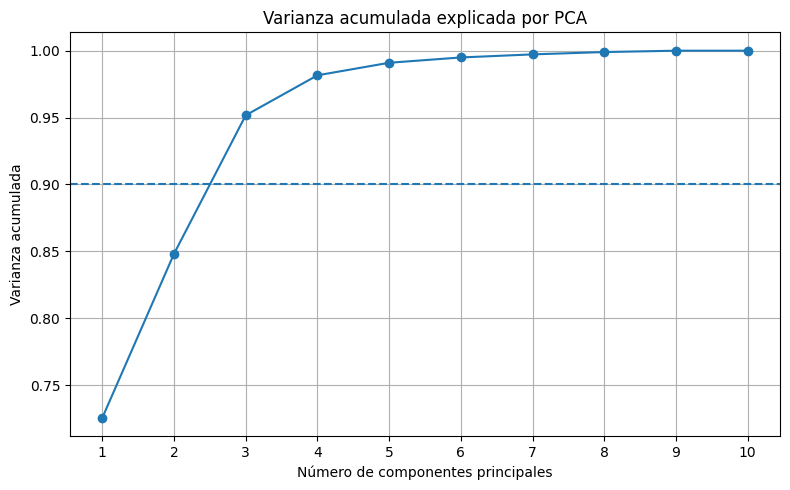

In [41]:
# Gráfica de varianza acumulada
plt.figure(figsize=(8, 5))
plt.plot(varianza_explicada["Componente"], varianza_explicada["Varianza_Acumulada"], marker="o")
plt.axhline(y=0.90, linestyle="--")
plt.title("Varianza acumulada explicada por PCA")
plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza acumulada")
plt.xticks(varianza_explicada["Componente"])
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "pca_varianza_acumulada.png"), dpi=300, bbox_inches="tight")
plt.show()

In [42]:
# PCA final con componentes necesarios para conservar al menos 90% de varianza
pca = PCA(n_components=n_componentes_90, random_state=RANDOM_STATE)
X_cluster_pca = pca.fit_transform(X_cluster_scaled)

print("Shape original escalado:", X_cluster_scaled.shape)
print("Shape con PCA:", X_cluster_pca.shape)
print("Varianza total explicada:", pca.explained_variance_ratio_.sum())

Shape original escalado: (5383, 10)
Shape con PCA: (5383, 3)
Varianza total explicada: 0.9517218385174904


/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


# 10. Evaluación de K-Means con PCA

Se vuelve a evaluar K-Means, ahora usando los componentes principales. El objetivo es determinar si PCA mejora la separación y compactación de los clusters.

In [43]:
resultados_kmeans_pca = []

for k in range(2, 11):
    kmeans_pca = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans_pca.fit_predict(X_cluster_pca)
    metrics = evaluate_clustering(X_cluster_pca, labels)

    resultados_kmeans_pca.append({
        "K": k,
        "Inertia_PCA": kmeans_pca.inertia_,
        "Silhouette_PCA": metrics["Silhouette"],
        "Davies_Bouldin_PCA": metrics["Davies_Bouldin"],
        "Calinski_Harabasz_PCA": metrics["Calinski_Harabasz"]
    })

df_resultados_kmeans_pca = pd.DataFrame(resultados_kmeans_pca)
display(df_resultados_kmeans_pca)

/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github

,K,Inertia_PCA,Silhouette_PCA,Davies_Bouldin_PCA,Calinski_Harabasz_PCA
0,2,28543.897721,0.549681,0.880783,4276.931710
1,3,20735.508895,0.410841,0.957046,3956.208837
2,4,17388.794878,0.352322,1.020992,3489.598296
3,5,15018.451149,0.366808,0.969880,3241.882482
4,6,13098.479565,0.337028,0.986196,3130.747894
5,7,11357.912334,0.324567,0.954433,3145.581606
6,8,10445.085902,0.302943,0.990878,2998.400433
7,9,9655.739736,0.294372,1.034645,2892.431192
8,10,8901.739309,0.288230,1.022854,2838.885030


In [44]:
# Comparación directa K-Means sin PCA vs con PCA
comparacion_kmeans = df_resultados_kmeans.merge(
    df_resultados_kmeans_pca,
    on="K",
    how="inner"
)

comparacion_kmeans["Delta_Silhouette"] = comparacion_kmeans["Silhouette_PCA"] - comparacion_kmeans["Silhouette"]
comparacion_kmeans["Mejora_Davies_Bouldin"] = comparacion_kmeans["Davies_Bouldin"] - comparacion_kmeans["Davies_Bouldin_PCA"]
comparacion_kmeans["Delta_Calinski_Harabasz"] = comparacion_kmeans["Calinski_Harabasz_PCA"] - comparacion_kmeans["Calinski_Harabasz"]

display(comparacion_kmeans.round(4))

,K,Inertia,Silhouette,Davies_Bouldin,Calinski_Harabasz,Inertia_PCA,Silhouette_PCA,Davies_Bouldin_PCA,Calinski_Harabasz_PCA,Delta_Silhouette,Mejora_Davies_Bouldin,Delta_Calinski_Harabasz
0,2,31139.3380,0.5381,0.9284,3921.0356,28543.8977,0.5497,0.8808,4276.9317,0.0116,0.0476,355.8961
1,3,23267.3916,0.3925,1.0170,3533.4191,20735.5089,0.4108,0.9570,3956.2088,0.0183,0.0599,422.7898
2,4,19916.4935,0.3493,1.0740,3053.0944,17388.7949,0.3523,1.0210,3489.5983,0.0030,0.0530,436.5039
3,5,17472.6646,0.3460,1.0530,2797.6521,15018.4511,0.3668,0.9699,3241.8825,0.0208,0.0831,444.2304
4,6,15538.0792,0.3140,1.0645,2650.2073,13098.4796,0.3370,0.9862,3130.7479,0.0231,0.0783,480.5406
5,7,13762.6363,0.2957,1.0575,2608.5408,11357.9123,0.3246,0.9544,3145.5816,0.0289,0.1031,537.0409
6,8,12820.7600,0.2841,1.1007,2456.1140,10445.0859,0.3029,0.9909,2998.4004,0.0188,0.1098,542.2864
7,9,12089.5965,0.2717,1.1256,2319.2871,9655.7397,0.2944,1.0346,2892.4312,0.0227,0.0910,573.1441
8,10,11285.5104,0.2550,1.1473,2250.5972,8901.7393,0.2882,1.0229,2838.8850,0.0332,0.1245,588.2878


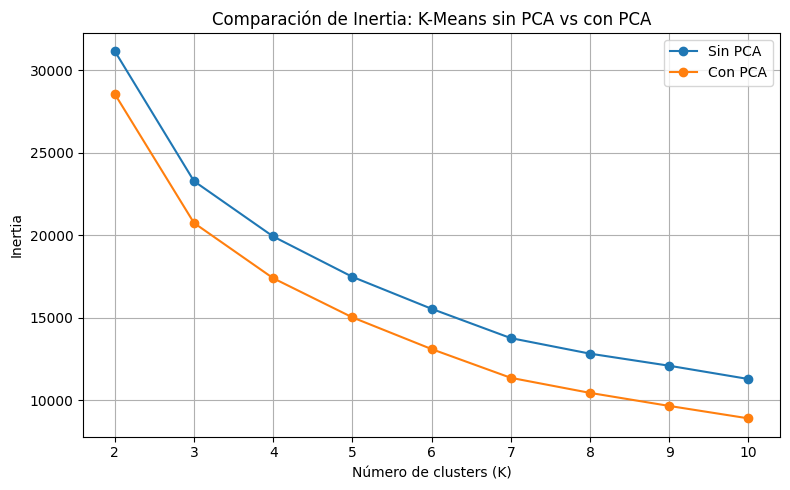

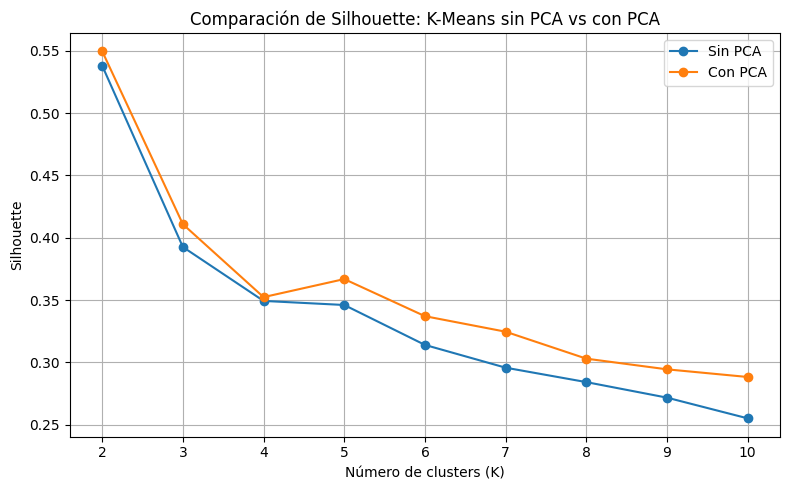

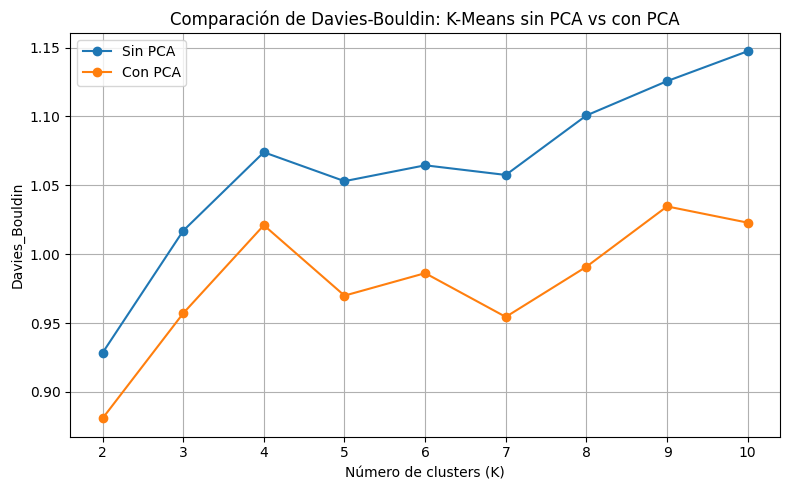

In [45]:
# Gráficas comparativas K-Means sin PCA vs con PCA
metric_pairs = [
    ("Inertia", "Inertia_PCA", "Comparación de Inertia: K-Means sin PCA vs con PCA"),
    ("Silhouette", "Silhouette_PCA", "Comparación de Silhouette: K-Means sin PCA vs con PCA"),
    ("Davies_Bouldin", "Davies_Bouldin_PCA", "Comparación de Davies-Bouldin: K-Means sin PCA vs con PCA")
]

for metric_original, metric_pca, title in metric_pairs:
    plt.figure(figsize=(8, 5))
    plt.plot(comparacion_kmeans["K"], comparacion_kmeans[metric_original], marker="o", label="Sin PCA")
    plt.plot(comparacion_kmeans["K"], comparacion_kmeans[metric_pca], marker="o", label="Con PCA")
    plt.title(title)
    plt.xlabel("Número de clusters (K)")
    plt.ylabel(metric_original)
    plt.xticks(comparacion_kmeans["K"])
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(IMAGES_DIR, f"comparacion_kmeans_{metric_original}.png"), dpi=300, bbox_inches="tight")
    plt.show()

## Interpretación de K-Means con PCA

PCA mejora ligeramente el desempeño de K-Means. La mejor configuración sigue siendo **K = 2**, pero con PCA se obtiene una mejor separación y compactación de clusters frente al modelo sin PCA. Se puede considerar a K = 3 como una opción para ofrecer mayor valor comercial.

Por ahora, K-Means + PCA se considera el modelo principal más interpretable para segmentación general.

# 11. Entrenamiento del modelo K-Means + PCA con K = 2

Se entrena K-Means + PCA con `K = 2` para obtener una segmentación principal de hogares. Este modelo se conserva como referencia interpretativa porque genera grupos accionables y estables.

In [46]:
k_final = 2

kmeans_final_pca = KMeans(
    n_clusters=k_final,
    random_state=RANDOM_STATE,
    n_init=10
)

hogar_cluster["cluster_kmeans_pca"] = kmeans_final_pca.fit_predict(X_cluster_pca)

display(hogar_cluster[["LCLid", "cluster_kmeans_pca"]].head())

/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github

,LCLid,cluster_kmeans_pca
0,MAC000002,0
1,MAC000003,1
2,MAC000004,0
3,MAC000005,0
4,MAC000006,0


In [47]:
# Distribución de hogares por cluster K-Means + PCA
distribucion_kmeans_pca = (
    hogar_cluster["cluster_kmeans_pca"]
    .value_counts()
    .sort_index()
    .reset_index()
)

distribucion_kmeans_pca.columns = ["cluster_kmeans_pca", "hogares"]
distribucion_kmeans_pca["porcentaje"] = (
    distribucion_kmeans_pca["hogares"] / distribucion_kmeans_pca["hogares"].sum() * 100
).round(2)

display(distribucion_kmeans_pca)

,cluster_kmeans_pca,hogares,porcentaje
0,0,4474,83.11
1,1,909,16.89


In [48]:
# Perfil promedio de consumo por cluster K-Means + PCA
perfil_kmeans_pca = (
    hogar_cluster
    .groupby("cluster_kmeans_pca")
    .agg(
        hogares=("LCLid", "count"),
        consumo_total_promedio=("consumo_total", "mean"),
        consumo_medio_diario=("consumo_medio", "mean"),
        variabilidad_promedio=("consumo_std", "mean"),
        consumo_max_promedio=("consumo_max", "mean"),
        consumo_invierno_promedio=("consumo_invierno", "mean"),
        consumo_verano_promedio=("consumo_verano", "mean"),
        consumo_finde_promedio=("consumo_finde", "mean"),
        consumo_semana_promedio=("consumo_semana", "mean"),
        ratio_invierno_verano=("ratio_invierno_verano_clip", "mean"),
        dias_promedio=("dias_registrados", "mean")
    )
    .round(2)
)

display(perfil_kmeans_pca)

,hogares,consumo_total_promedio,consumo_medio_diario,variabilidad_promedio,consumo_max_promedio,consumo_invierno_promedio,consumo_verano_promedio,consumo_finde_promedio,consumo_semana_promedio,ratio_invierno_verano,dias_promedio
cluster_kmeans_pca,,,,,,,,,,,
0,4474,4892.87,7.72,2.67,20.34,8.70,6.71,8.05,7.59,1.35,636.38
1,909,14114.45,22.28,9.81,60.18,28.45,15.76,22.72,22.11,2.08,636.58


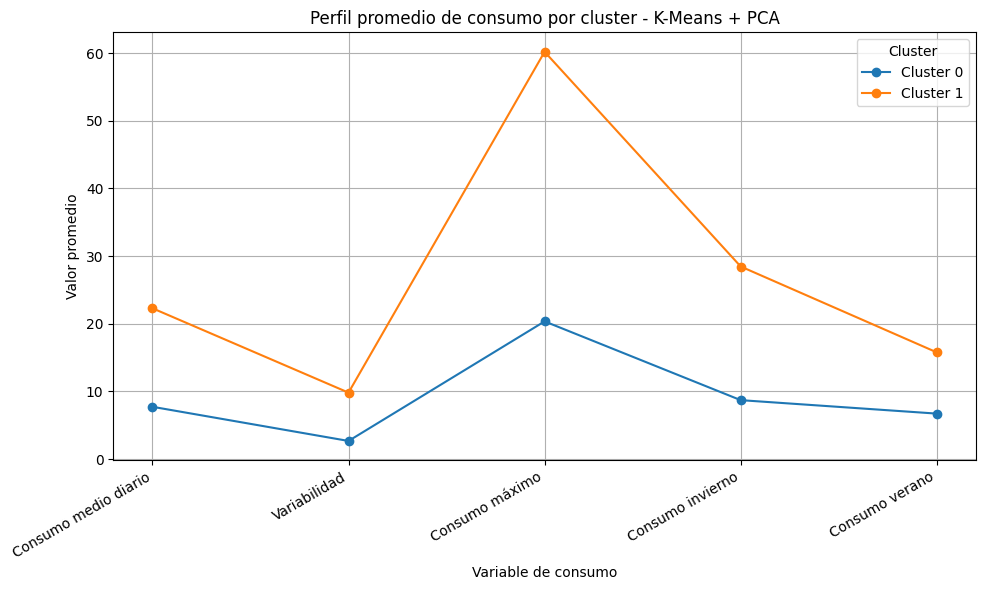

In [49]:
# Gráfica de perfil promedio por cluster K-Means + PCA
perfil_plot = perfil_kmeans_pca.reset_index()
variables_grafica = [
    "consumo_medio_diario",
    "variabilidad_promedio",
    "consumo_max_promedio",
    "consumo_invierno_promedio",
    "consumo_verano_promedio"
]

perfil_long = perfil_plot.melt(
    id_vars="cluster_kmeans_pca",
    value_vars=variables_grafica,
    var_name="variable",
    value_name="valor"
)

nombres_variables = {
    "consumo_medio_diario": "Consumo medio diario",
    "variabilidad_promedio": "Variabilidad",
    "consumo_max_promedio": "Consumo máximo",
    "consumo_invierno_promedio": "Consumo invierno",
    "consumo_verano_promedio": "Consumo verano"
}
perfil_long["variable"] = perfil_long["variable"].map(nombres_variables)

plt.figure(figsize=(10, 6))
for cluster in sorted(perfil_long["cluster_kmeans_pca"].unique()):
    data_cluster = perfil_long[perfil_long["cluster_kmeans_pca"] == cluster]
    plt.plot(data_cluster["variable"], data_cluster["valor"], marker="o", label=f"Cluster {cluster}")

plt.title("Perfil promedio de consumo por cluster - K-Means + PCA")
plt.xlabel("Variable de consumo")
plt.ylabel("Valor promedio")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "perfil_consumo_kmeans_pca.png"), dpi=300, bbox_inches="tight")
plt.show()

/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


Varianza explicada PCA 2D: [0.72554384 0.1226445 ]
Varianza total PCA 2D: 0.8481883429462364


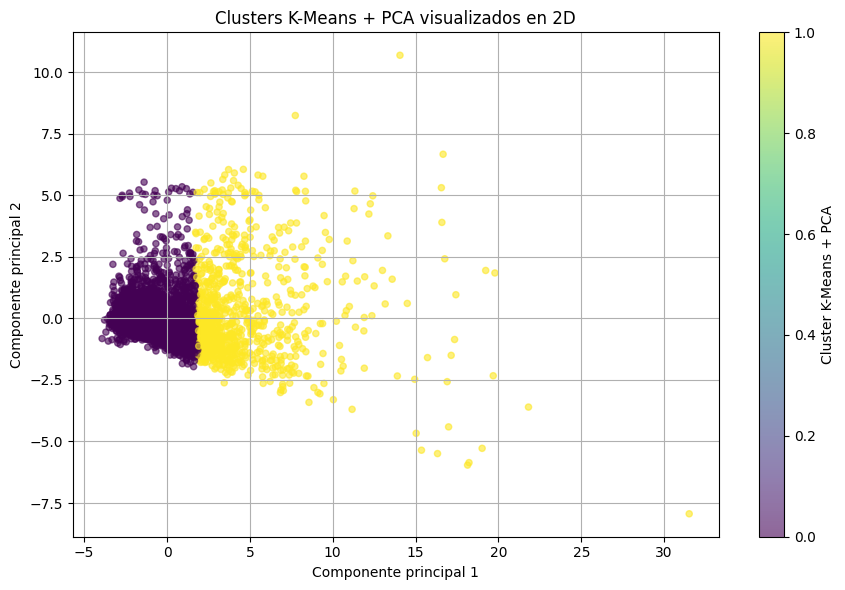

In [50]:
# Visualización 2D de clusters K-Means + PCA
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_cluster_scaled)

hogar_cluster["PCA_1"] = X_pca_2d[:, 0]
hogar_cluster["PCA_2"] = X_pca_2d[:, 1]

print("Varianza explicada PCA 2D:", pca_2d.explained_variance_ratio_)
print("Varianza total PCA 2D:", pca_2d.explained_variance_ratio_.sum())

plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    hogar_cluster["PCA_1"],
    hogar_cluster["PCA_2"],
    c=hogar_cluster["cluster_kmeans_pca"],
    alpha=0.6,
    s=20
)
plt.title("Clusters K-Means + PCA visualizados en 2D")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.colorbar(scatter, label="Cluster K-Means + PCA")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "clusters_kmeans_pca_2d.png"), dpi=300, bbox_inches="tight")
plt.show()

## Conclusión parcial de K-Means + PCA K = 2

El modelo K-Means + PCA identifica dos grupos principales:

- **Cluster 0:** hogares de consumo bajo-medio, con menor variabilidad y picos más controlados.
- **Cluster 1:** hogares de alto consumo, mayor variabilidad, mayores picos y mayor sensibilidad al invierno.

Esta segmentación es simple, pero útil para tomar decisiones: campañas generales para el grupo mayoritario y acciones focalizadas para hogares de alto consumo.

# 12. Entrenamiento del modelo K-Means + PCA con K = 3

Se replica el entrenamiento K-Means + PCA usando `K = 3` para evaluar una segmentación más granular. Esta versión permite contrastar si dividir los hogares en tres grupos aporta una lectura más útil que la segmentación principal con `K = 2`.

In [ ]:
k_final_3 = 3

kmeans_final_pca_k3 = KMeans(
    n_clusters=k_final_3,
    random_state=RANDOM_STATE,
    n_init=10
)

hogar_cluster["cluster_kmeans_pca_k3"] = kmeans_final_pca_k3.fit_predict(X_cluster_pca)

display(hogar_cluster[["LCLid", "cluster_kmeans_pca_k3"]].head())

In [ ]:
# Distribución de hogares por cluster K-Means + PCA con K = 3
distribucion_kmeans_pca_k3 = (
    hogar_cluster["cluster_kmeans_pca_k3"]
    .value_counts()
    .sort_index()
    .reset_index()
)

distribucion_kmeans_pca_k3.columns = ["cluster_kmeans_pca_k3", "hogares"]
distribucion_kmeans_pca_k3["porcentaje"] = (
    distribucion_kmeans_pca_k3["hogares"] / distribucion_kmeans_pca_k3["hogares"].sum() * 100
).round(2)

display(distribucion_kmeans_pca_k3)

In [ ]:
# Perfil promedio de consumo por cluster K-Means + PCA con K = 3
perfil_kmeans_pca_k3 = (
    hogar_cluster
    .groupby("cluster_kmeans_pca_k3")
    .agg(
        hogares=("LCLid", "count"),
        consumo_total_promedio=("consumo_total", "mean"),
        consumo_medio_diario=("consumo_medio", "mean"),
        variabilidad_promedio=("consumo_std", "mean"),
        consumo_max_promedio=("consumo_max", "mean"),
        consumo_invierno_promedio=("consumo_invierno", "mean"),
        consumo_verano_promedio=("consumo_verano", "mean"),
        consumo_finde_promedio=("consumo_finde", "mean"),
        consumo_semana_promedio=("consumo_semana", "mean"),
        ratio_invierno_verano=("ratio_invierno_verano_clip", "mean"),
        dias_promedio=("dias_registrados", "mean")
    )
    .round(2)
)

display(perfil_kmeans_pca_k3)

In [ ]:
# Gráfica de perfil promedio por cluster K-Means + PCA con K = 3
perfil_plot_k3 = perfil_kmeans_pca_k3.reset_index()
variables_grafica_k3 = [
    "consumo_medio_diario",
    "variabilidad_promedio",
    "consumo_max_promedio",
    "consumo_invierno_promedio",
    "consumo_verano_promedio"
]

perfil_long_k3 = perfil_plot_k3.melt(
    id_vars="cluster_kmeans_pca_k3",
    value_vars=variables_grafica_k3,
    var_name="variable",
    value_name="valor"
)

nombres_variables_k3 = {
    "consumo_medio_diario": "Consumo medio diario",
    "variabilidad_promedio": "Variabilidad",
    "consumo_max_promedio": "Consumo máximo",
    "consumo_invierno_promedio": "Consumo invierno",
    "consumo_verano_promedio": "Consumo verano"
}
perfil_long_k3["variable"] = perfil_long_k3["variable"].map(nombres_variables_k3)

plt.figure(figsize=(10, 6))
for cluster in sorted(perfil_long_k3["cluster_kmeans_pca_k3"].unique()):
    data_cluster = perfil_long_k3[perfil_long_k3["cluster_kmeans_pca_k3"] == cluster]
    plt.plot(data_cluster["variable"], data_cluster["valor"], marker="o", label=f"Cluster {cluster}")

plt.title("Perfil promedio de consumo por cluster - K-Means + PCA K = 3")
plt.xlabel("Variable de consumo")
plt.ylabel("Valor promedio")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "perfil_consumo_kmeans_pca_k3.png"), dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Visualización 2D de clusters K-Means + PCA con K = 3
plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    hogar_cluster["PCA_1"],
    hogar_cluster["PCA_2"],
    c=hogar_cluster["cluster_kmeans_pca_k3"],
    alpha=0.6,
    s=20
)
plt.title("Clusters K-Means + PCA con K = 3 visualizados en 2D")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.colorbar(scatter, label="Cluster K-Means + PCA K = 3")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "clusters_kmeans_pca_k3_2d.png"), dpi=300, bbox_inches="tight")
plt.show()

## Conclusión parcial de K-Means + PCA K = 3

El modelo K-Means + PCA con `K = 3` permite revisar si existe un grupo intermedio entre hogares de menor consumo y hogares de consumo alto. La utilidad de esta segmentación debe evaluarse con la distribución de hogares, el perfil promedio de cada cluster y la comparación posterior de métricas frente a `K = 2`.

# 13. Evaluación exploratoria de DBSCAN

DBSCAN se evalúa como modelo alternativo porque puede detectar agrupaciones basadas en densidad y hogares atípicos. A diferencia de K-Means, DBSCAN no requiere definir previamente el número de clusters y puede clasificar observaciones como ruido (`-1`).

En esta libreta, DBSCAN se prueba sobre `X_cluster_pca`, es decir, los componentes principales obtenidos con las mismas variables actuales.

In [58]:
resultados_dbscan = []

eps_values = [0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 2.0]
min_samples_values = [5, 10, 20, 30, 50]

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_cluster_pca)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_ruido = np.sum(labels == -1)
        porcentaje_ruido = n_ruido / len(labels) * 100
        metrics = evaluate_clustering(X_cluster_pca, labels)

        resultados_dbscan.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "n_ruido": n_ruido,
            "porcentaje_ruido": porcentaje_ruido,
            **metrics
        })

df_resultados_dbscan = pd.DataFrame(resultados_dbscan)

display(
    df_resultados_dbscan
    .sort_values(by=["Silhouette", "n_clusters"], ascending=[False, False])
    .round(4)
)

/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/pyt

,eps,min_samples,n_clusters,n_ruido,porcentaje_ruido,Silhouette,Davies_Bouldin,Calinski_Harabasz
35,2.0,5,2,20,0.3715,0.7937,0.2067,182.2319
30,1.5,5,2,34,0.6316,0.6914,0.2865,102.1872
25,1.3,5,5,56,1.0403,0.6697,0.5189,111.7743
11,0.7,10,2,438,8.1367,0.6008,0.3445,175.0853
16,0.9,10,2,280,5.2016,0.5814,0.4231,158.8946
21,1.1,10,2,164,3.0466,0.4618,0.5634,45.2318
6,0.5,10,2,745,13.8399,0.4124,0.4957,45.5240
15,0.9,5,4,168,3.1209,0.3851,0.4988,51.1402
10,0.7,5,13,273,5.0715,0.3367,0.5743,52.5248
2,0.3,20,3,2203,40.9251,0.2562,0.9650,393.8762


## Lectura inicial de DBSCAN

DBSCAN muestra configuraciones con métricas altas. Sin embargo, antes de elegirlo como modelo principal es necesario revisar la distribución de hogares por cluster, porque un alto Silhouette puede deberse a microclusters muy separados y no necesariamente a una segmentación accionable.

# 14. Comparación de modelos

Se comparan cinco alternativas relevantes:

1. K-Means sin PCA con K = 2.
2. K-Means con PCA con K = 2.
3. K-Means con PCA con K = 3.
4. DBSCAN con PCA usando `eps = 1.3`, `min_samples = 5`.
5. DBSCAN con PCA usando `eps = 2.0`, `min_samples = 5`.

La primera configuración de DBSCAN ofrece más clusters; la segunda ofrece las mejores métricas globales, pero solo produce 2 clusters.

In [52]:
comparacion_final = []

# K-Means sin PCA, K=2
fila_kmeans = df_resultados_kmeans[df_resultados_kmeans["K"] == 2].iloc[0]
comparacion_final.append({
    "Modelo": "K-Means",
    "Configuracion": "K=2, sin PCA",
    "Clusters": 2,
    "Ruido_%": 0,
    "Silhouette": fila_kmeans["Silhouette"],
    "Davies_Bouldin": fila_kmeans["Davies_Bouldin"],
    "Calinski_Harabasz": fila_kmeans["Calinski_Harabasz"]
})

# K-Means con PCA, K=2
fila_kmeans_pca = df_resultados_kmeans_pca[df_resultados_kmeans_pca["K"] == 2].iloc[0]
comparacion_final.append({
    "Modelo": "K-Means + PCA",
    "Configuracion": f"K=2, PCA={n_componentes_90} componentes",
    "Clusters": 2,
    "Ruido_%": 0,
    "Silhouette": fila_kmeans_pca["Silhouette_PCA"],
    "Davies_Bouldin": fila_kmeans_pca["Davies_Bouldin_PCA"],
    "Calinski_Harabasz": fila_kmeans_pca["Calinski_Harabasz_PCA"]
})

# K-Means con PCA, K=3
fila_kmeans_pca_k3 = df_resultados_kmeans_pca[df_resultados_kmeans_pca["K"] == 3].iloc[0]
comparacion_final.append({
    "Modelo": "K-Means + PCA",
    "Configuracion": f"K=3, PCA={n_componentes_90} componentes",
    "Clusters": 3,
    "Ruido_%": 0,
    "Silhouette": fila_kmeans_pca_k3["Silhouette_PCA"],
    "Davies_Bouldin": fila_kmeans_pca_k3["Davies_Bouldin_PCA"],
    "Calinski_Harabasz": fila_kmeans_pca_k3["Calinski_Harabasz_PCA"]
})

# DBSCAN granular: eps=1.3, min_samples=5
for eps, min_samples in [(1.3, 5), (2.0, 5)]:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_cluster_pca)
    metrics = evaluate_clustering(X_cluster_pca, labels)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    ruido = np.mean(labels == -1) * 100

    comparacion_final.append({
        "Modelo": "DBSCAN + PCA",
        "Configuracion": f"eps={eps}, min_samples={min_samples}",
        "Clusters": n_clusters,
        "Ruido_%": ruido,
        **metrics
    })

df_comparacion_final = pd.DataFrame(comparacion_final).round({
    "Ruido_%": 2,
    "Silhouette": 4,
    "Davies_Bouldin": 4,
    "Calinski_Harabasz": 2
})

display(df_comparacion_final)

/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/pyt

,Modelo,Configuracion,Clusters,Ruido_%,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,K-Means,"K=2, sin PCA",2,0.00,0.5381,0.9284,3921.04
1,K-Means + PCA,"K=2, PCA=3 componentes",2,0.00,0.5497,0.8808,4276.93
2,DBSCAN + PCA,"eps=1.3, min_samples=5",5,1.04,0.6697,0.5189,111.77
3,DBSCAN + PCA,"eps=2.0, min_samples=5",2,0.37,0.7937,0.2067,182.23


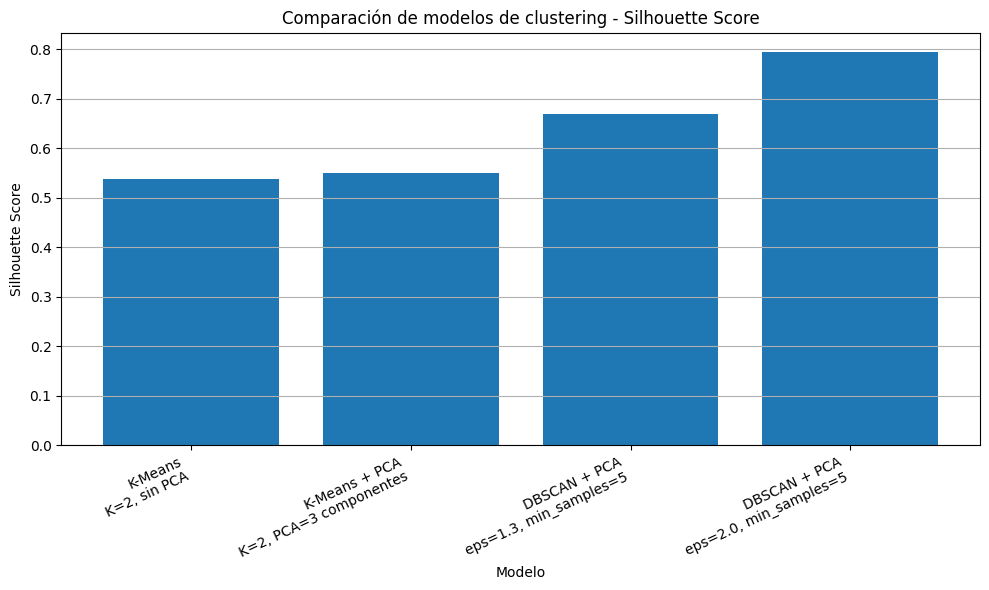

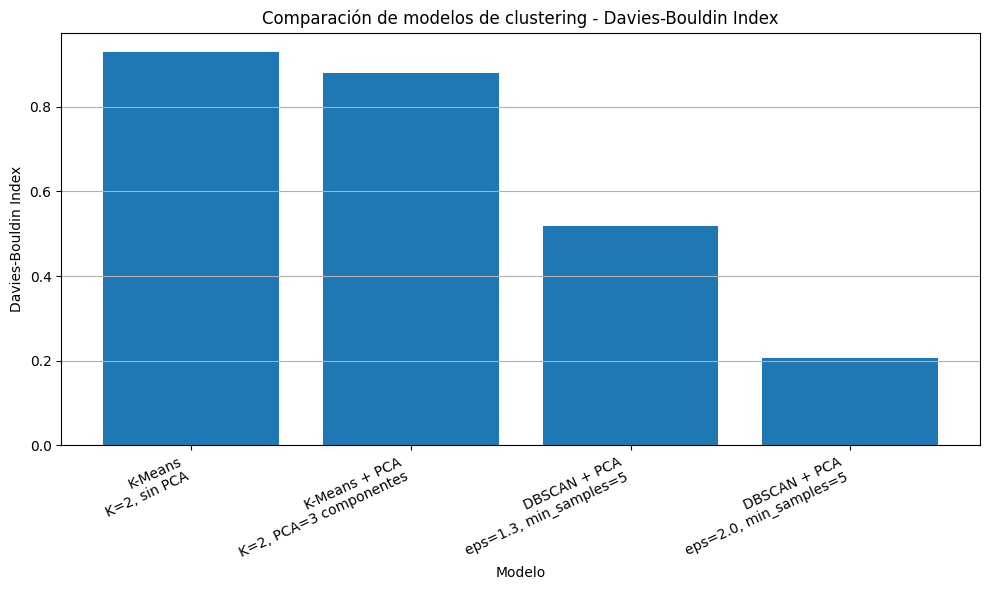

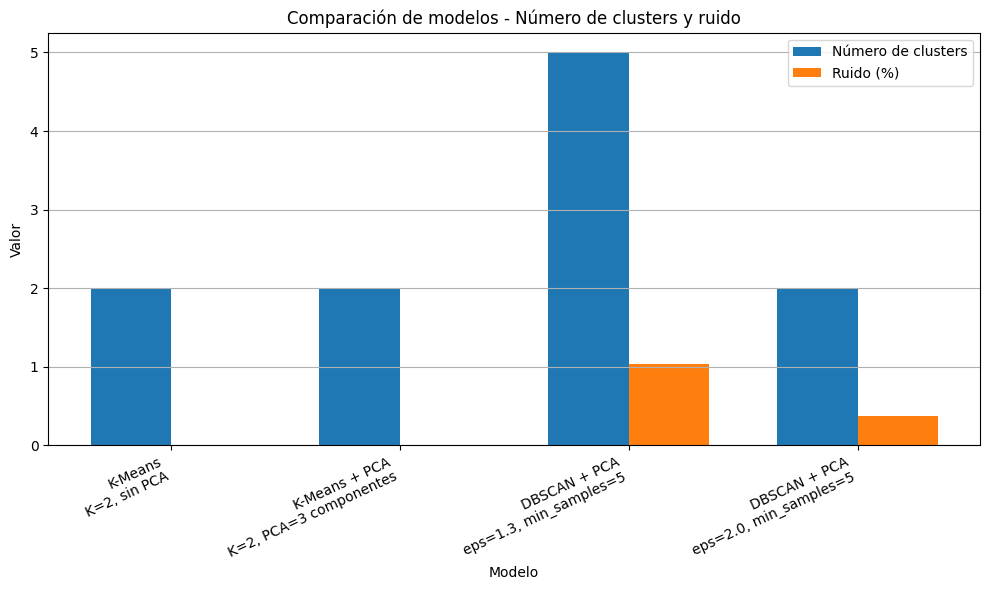

In [53]:
# Gráficas de comparación de modelos
df_plot = df_comparacion_final.copy()
df_plot["Modelo_Config"] = df_plot["Modelo"] + "\n" + df_plot["Configuracion"]

# Silhouette
plt.figure(figsize=(10, 6))
plt.bar(df_plot["Modelo_Config"], df_plot["Silhouette"])
plt.title("Comparación de modelos de clustering - Silhouette Score")
plt.xlabel("Modelo")
plt.ylabel("Silhouette Score")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "comparacion_modelos_silhouette.png"), dpi=300, bbox_inches="tight")
plt.show()

# Davies-Bouldin
plt.figure(figsize=(10, 6))
plt.bar(df_plot["Modelo_Config"], df_plot["Davies_Bouldin"])
plt.title("Comparación de modelos de clustering - Davies-Bouldin Index")
plt.xlabel("Modelo")
plt.ylabel("Davies-Bouldin Index")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "comparacion_modelos_davies_bouldin.png"), dpi=300, bbox_inches="tight")
plt.show()

# Clusters y ruido
x = np.arange(len(df_plot))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width / 2, df_plot["Clusters"], width, label="Número de clusters")
plt.bar(x + width / 2, df_plot["Ruido_%"], width, label="Ruido (%)")
plt.title("Comparación de modelos - Número de clusters y ruido")
plt.xlabel("Modelo")
plt.ylabel("Valor")
plt.xticks(x, df_plot["Modelo_Config"], rotation=25, ha="right")
plt.legend()
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "comparacion_modelos_clusters_ruido.png"), dpi=300, bbox_inches="tight")
plt.show()

# 15. Revisión de distribución de DBSCAN

Aunque DBSCAN con `eps = 1.3` y `min_samples = 5` produce 5 clusters y métricas atractivas, se revisa su distribución para validar si los grupos son útiles para una segmentación de negocio.

In [59]:
# DBSCAN seleccionado para revisión exploratoria, no como modelo final definitivo
dbscan_review = DBSCAN(eps=1.3, min_samples=5)
hogar_cluster["cluster_dbscan_review"] = dbscan_review.fit_predict(X_cluster_pca)

# Distribución de clusters DBSCAN
distribucion_dbscan_review = (
    hogar_cluster["cluster_dbscan_review"]
    .value_counts()
    .sort_index()
    .reset_index()
)

distribucion_dbscan_review.columns = ["cluster_dbscan_review", "hogares"]
distribucion_dbscan_review["porcentaje"] = (
    distribucion_dbscan_review["hogares"] / distribucion_dbscan_review["hogares"].sum() * 100
).round(2)

display(distribucion_dbscan_review)

,cluster_dbscan_review,hogares,porcentaje
0,-1,56,1.04
1,0,5304,98.53
2,1,5,0.09
3,2,7,0.13
4,3,6,0.11
5,4,5,0.09


In [60]:
# Perfil de clusters DBSCAN para análisis complementario
perfil_dbscan_review = (
    hogar_cluster
    .groupby("cluster_dbscan_review")
    .agg(
        hogares=("LCLid", "count"),
        consumo_total_promedio=("consumo_total", "mean"),
        consumo_medio_diario=("consumo_medio", "mean"),
        variabilidad_promedio=("consumo_std", "mean"),
        consumo_max_promedio=("consumo_max", "mean"),
        consumo_invierno_promedio=("consumo_invierno", "mean"),
        consumo_verano_promedio=("consumo_verano", "mean"),
        consumo_finde_promedio=("consumo_finde", "mean"),
        consumo_semana_promedio=("consumo_semana", "mean"),
        ratio_invierno_verano=("ratio_invierno_verano_clip", "mean"),
        dias_promedio=("dias_registrados", "mean")
    )
    .round(2)
)

display(perfil_dbscan_review)

,hogares,consumo_total_promedio,consumo_medio_diario,variabilidad_promedio,consumo_max_promedio,consumo_invierno_promedio,consumo_verano_promedio,consumo_finde_promedio,consumo_semana_promedio,ratio_invierno_verano,dias_promedio
cluster_dbscan_review,,,,,,,,,,,
-1,56,25531.11,41.74,22.39,124.56,56.35,26.60,41.10,41.99,2.99,596.88
0,5304,6170.15,9.72,3.61,25.70,11.38,7.98,10.08,9.58,1.45,636.90
1,5,26284.66,37.42,27.71,129.28,63.22,12.69,35.95,38.00,4.81,701.40
2,7,25810.88,40.01,23.55,117.90,59.33,19.86,40.51,39.82,3.00,646.14
3,6,25479.63,39.34,10.81,79.82,43.58,35.01,39.74,39.18,1.25,647.83
4,5,19908.07,41.79,17.48,88.02,54.87,24.20,40.29,42.39,2.30,476.20


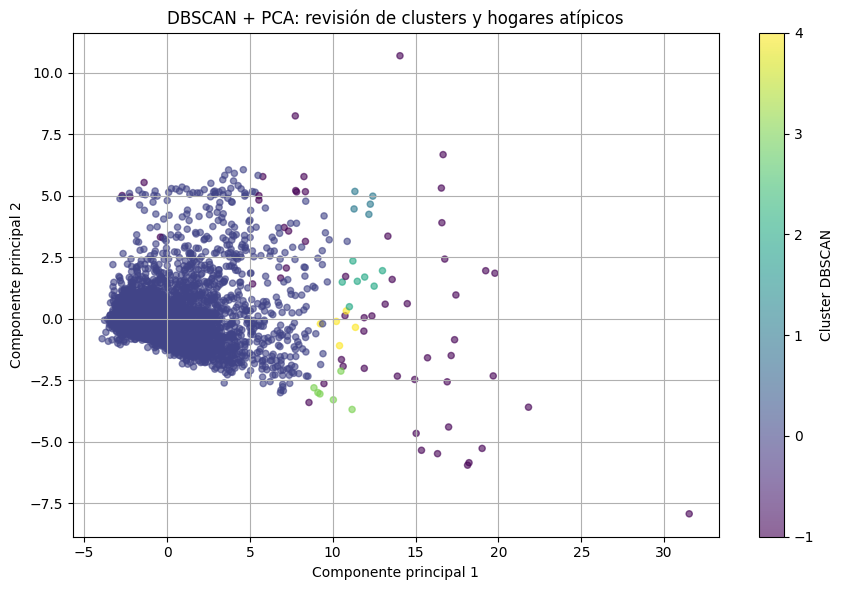

In [61]:
# Visualización 2D de DBSCAN exploratorio
plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    hogar_cluster["PCA_1"],
    hogar_cluster["PCA_2"],
    c=hogar_cluster["cluster_dbscan_review"],
    alpha=0.6,
    s=20
)
plt.title("DBSCAN + PCA: revisión de clusters y hogares atípicos")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.colorbar(scatter, label="Cluster DBSCAN")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "clusters_dbscan_review_2d.png"), dpi=300, bbox_inches="tight")
plt.show()

## Interpretación de DBSCAN

La distribución de DBSCAN debe revisarse antes de seleccionarlo como modelo principal. En la corrida observada durante el análisis, la configuración `eps = 1.3` y `min_samples = 5` generó 5 clusters, pero concentró aproximadamente el 98.53% de los hogares en un solo cluster y dejó los demás clusters como microgrupos de 5 a 7 hogares.

Esto indica que DBSCAN es útil para detectar hogares atípicos o pequeños grupos extremos, pero **no es ideal como modelo principal de segmentación ejecutiva**, ya que no genera grupos balanceados ni accionables para campañas diferenciadas a gran escala.

## Revisión de la distribución DBScan con mejores metricas técnicas

In [62]:
dbscan_20 = DBSCAN(eps=2.0, min_samples=5)
hogar_cluster['cluster_dbscan_20'] = dbscan_20.fit_predict(X_cluster_pca)

distribucion_dbscan_20 = (
    hogar_cluster['cluster_dbscan_20']
    .value_counts()
    .sort_index()
    .reset_index()
)

distribucion_dbscan_20.columns = ['cluster_dbscan_20', 'hogares']

distribucion_dbscan_20['porcentaje'] = (
    distribucion_dbscan_20['hogares'] / distribucion_dbscan_20['hogares'].sum() * 100
).round(2)

display(distribucion_dbscan_20)

,cluster_dbscan_20,hogares,porcentaje
0,-1,20,0.37
1,0,5358,99.54
2,1,5,0.09


# 16. Conclusión del modelo seleccionado

Después de comparar los modelos evaluados, se selecciona **K-Means + PCA con K = 3** como modelo final para la segmentación de hogares.

Aunque el modelo K-Means + PCA con `K = 2` presenta mejores métricas globales, el modelo con `K = 3` mantiene valores razonables de evaluación: Silhouette mayor a 0.40, Davies-Bouldin menor a 1 y un Calinski-Harabasz cercano al obtenido con `K = 2`. Esto indica que la separación entre clusters sigue siendo aceptable y que el aumento en granularidad no deteriora de forma crítica la calidad del agrupamiento.

La principal razón para seleccionar `K = 3` es su mayor valor interpretativo. Esta configuración permite separar tres perfiles de consumo: hogares de bajo consumo, hogares de consumo medio y hogares de alto consumo con mayor dispersión. En particular, el cluster de consumo alto queda diferenciado del grupo intermedio, lo cual facilita identificar hogares con patrones más intensivos o variables y diseñar acciones específicas para ellos.

DBSCAN se conserva como análisis exploratorio complementario. Aunque algunas configuraciones obtienen métricas técnicas atractivas, su distribución concentra la mayoría de hogares en un solo grupo y deja microclusters o ruido, por lo que resulta menos adecuado como modelo principal de segmentación ejecutiva.

En conclusión, **K-Means + PCA con K = 3** ofrece el mejor equilibrio entre desempeño técnico, simplicidad e interpretación práctica para el objetivo del proyecto.

# 17. Entrenamiento final, resultados e interpretación con variables categóricas

En esta sección se reentrena el modelo seleccionado, **K-Means + PCA con K = 3**, y se consolidan sus resultados principales.

Las variables categóricas, como `stdorToU` y `Acorn_grouped`, no se incorporan al entrenamiento del clustering porque el objetivo es agrupar hogares con base en patrones numéricos de consumo. Estas variables se usan después para interpretar y validar si los clusters tienen sentido de negocio.

In [ ]:
# Entrenamiento del modelo final seleccionado: K-Means + PCA con K = 3
K_MODELO_FINAL = 3

modelo_final_kmeans_pca = KMeans(
    n_clusters=K_MODELO_FINAL,
    random_state=RANDOM_STATE,
    n_init=10
)

hogar_cluster["cluster_modelo_final"] = modelo_final_kmeans_pca.fit_predict(X_cluster_pca)

metricas_modelo_final = evaluate_clustering(
    X_cluster_pca,
    hogar_cluster["cluster_modelo_final"]
)

resumen_modelo_final = pd.DataFrame([
    {
        "modelo": "K-Means + PCA",
        "K": K_MODELO_FINAL,
        "componentes_pca": n_componentes_90,
        "varianza_explicada_pca": pca.explained_variance_ratio_.sum(),
        "inertia": modelo_final_kmeans_pca.inertia_,
        **metricas_modelo_final
    }
]).round({
    "varianza_explicada_pca": 4,
    "inertia": 2,
    "Silhouette": 4,
    "Davies_Bouldin": 4,
    "Calinski_Harabasz": 2
})

display(resumen_modelo_final)

In [ ]:
# Distribución de hogares por cluster del modelo final
distribucion_modelo_final = (
    hogar_cluster["cluster_modelo_final"]
    .value_counts()
    .sort_index()
    .reset_index()
)

distribucion_modelo_final.columns = ["cluster_modelo_final", "hogares"]
distribucion_modelo_final["porcentaje"] = (
    distribucion_modelo_final["hogares"] / distribucion_modelo_final["hogares"].sum() * 100
).round(2)

display(distribucion_modelo_final)

In [ ]:
# Perfil promedio de consumo por cluster del modelo final
perfil_modelo_final = (
    hogar_cluster
    .groupby("cluster_modelo_final")
    .agg(
        hogares=("LCLid", "count"),
        consumo_total_promedio=("consumo_total", "mean"),
        consumo_medio_diario=("consumo_medio", "mean"),
        variabilidad_promedio=("consumo_std", "mean"),
        consumo_max_promedio=("consumo_max", "mean"),
        consumo_invierno_promedio=("consumo_invierno", "mean"),
        consumo_verano_promedio=("consumo_verano", "mean"),
        consumo_finde_promedio=("consumo_finde", "mean"),
        consumo_semana_promedio=("consumo_semana", "mean"),
        ratio_invierno_verano=("ratio_invierno_verano_clip", "mean"),
        dias_promedio=("dias_registrados", "mean")
    )
    .round(2)
)

display(perfil_modelo_final)

In [ ]:
# Etiquetado interpretativo de clusters según el consumo promedio
orden_consumo = (
    perfil_modelo_final["consumo_medio_diario"]
    .sort_values()
    .index
    .tolist()
)

etiquetas_cluster = {
    orden_consumo[0]: "Bajo consumo",
    orden_consumo[1]: "Consumo medio",
    orden_consumo[2]: "Alto consumo / mayor dispersión"
}

hogar_cluster["segmento_modelo_final"] = hogar_cluster["cluster_modelo_final"].map(etiquetas_cluster)
perfil_modelo_final_etiquetado = perfil_modelo_final.copy()
perfil_modelo_final_etiquetado["segmento"] = perfil_modelo_final_etiquetado.index.map(etiquetas_cluster)

display(
    perfil_modelo_final_etiquetado
    .reset_index()
    [[
        "cluster_modelo_final",
        "segmento",
        "hogares",
        "consumo_medio_diario",
        "variabilidad_promedio",
        "consumo_max_promedio",
        "ratio_invierno_verano"
    ]]
)

In [ ]:
# Visualización del modelo final en dos componentes principales
plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    hogar_cluster["PCA_1"],
    hogar_cluster["PCA_2"],
    c=hogar_cluster["cluster_modelo_final"],
    alpha=0.6,
    s=20
)
plt.title("Modelo final: K-Means + PCA con K = 3")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.colorbar(scatter, label="Cluster modelo final")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "modelo_final_kmeans_pca_k3_2d.png"), dpi=300, bbox_inches="tight")
plt.show()

## Relación con variables categóricas

Las variables categóricas se analizan después del clustering para revisar si los segmentos obtenidos tienen coherencia externa. Si un cluster concentra mayor proporción de cierta tarifa o grupo ACORN, esa relación ayuda a describir el segmento, pero no significa que la categoría haya forzado la creación del cluster.

In [ ]:
# Cruce de clusters finales con variables categóricas disponibles
VARIABLES_CATEGORICAS = ["stdorToU", "Acorn_grouped"]
variables_categoricas_disponibles = [
    col for col in VARIABLES_CATEGORICAS
    if col in hogar_cluster.columns
]

print("Variables categóricas disponibles para interpretación:", variables_categoricas_disponibles)

tablas_categoricas = {}
tablas_categoricas_pct = {}

for col in variables_categoricas_disponibles:
    tabla = pd.crosstab(
        hogar_cluster["cluster_modelo_final"],
        hogar_cluster[col]
    )

    tabla_pct = pd.crosstab(
        hogar_cluster["cluster_modelo_final"],
        hogar_cluster[col],
        normalize="index"
    ).mul(100).round(2)

    tablas_categoricas[col] = tabla
    tablas_categoricas_pct[col] = tabla_pct

    print(f"\nDistribución absoluta por cluster y {col}:")
    display(tabla)

    print(f"Distribución porcentual por cluster y {col}:")
    display(tabla_pct)

In [ ]:
# Resumen dominante por cluster para cada variable categórica
resumen_categorico_modelo_final = []

for col, tabla_pct in tablas_categoricas_pct.items():
    for cluster in tabla_pct.index:
        categoria_dominante = tabla_pct.loc[cluster].idxmax()
        porcentaje_dominante = tabla_pct.loc[cluster].max()

        resumen_categorico_modelo_final.append({
            "variable_categorica": col,
            "cluster_modelo_final": cluster,
            "segmento": etiquetas_cluster.get(cluster),
            "categoria_dominante": categoria_dominante,
            "porcentaje_dominante": porcentaje_dominante
        })

resumen_categorico_modelo_final = pd.DataFrame(resumen_categorico_modelo_final)
display(resumen_categorico_modelo_final)

In [ ]:
# Gráficas de composición porcentual por variable categórica
for col, tabla_pct in tablas_categoricas_pct.items():
    ax = tabla_pct.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 6),
        colormap="tab20"
    )
    plt.title(f"Composición de {col} por cluster del modelo final")
    plt.xlabel("Cluster modelo final")
    plt.ylabel("Porcentaje de hogares")
    plt.xticks(rotation=0)
    plt.legend(title=col, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.savefig(os.path.join(IMAGES_DIR, f"relacion_cluster_modelo_final_{col}.png"), dpi=300, bbox_inches="tight")
    plt.show()

In [ ]:
# Exportación de resultados del modelo final
COLUMNAS_EXPORTACION = [
    "LCLid",
    "cluster_modelo_final",
    "segmento_modelo_final",
    "stdorToU",
    "Acorn_grouped",
    *FEATURES_CLUSTERING
]

COLUMNAS_EXPORTACION = [
    col for col in COLUMNAS_EXPORTACION
    if col in hogar_cluster.columns
]

hogar_cluster[COLUMNAS_EXPORTACION].to_csv(
    os.path.join(OUTPUT_DIR, "hogares_clusterizados_modelo_final_k3.csv"),
    index=False
)
resumen_modelo_final.to_csv(
    os.path.join(OUTPUT_DIR, "metricas_modelo_final_k3.csv"),
    index=False
)
distribucion_modelo_final.to_csv(
    os.path.join(OUTPUT_DIR, "distribucion_modelo_final_k3.csv"),
    index=False
)
perfil_modelo_final_etiquetado.to_csv(
    os.path.join(OUTPUT_DIR, "perfil_modelo_final_k3.csv")
)
resumen_categorico_modelo_final.to_csv(
    os.path.join(OUTPUT_DIR, "resumen_categorico_modelo_final_k3.csv"),
    index=False
)

print("Archivos exportados en:", OUTPUT_DIR)

## Interpretación final de la relación categórica

La relación entre clusters y variables categóricas debe leerse como una validación posterior. El modelo final fue entrenado únicamente con variables numéricas de consumo, por lo que cualquier patrón observado en `stdorToU` o `Acorn_grouped` aporta contexto de negocio sin introducir sesgo directo en la formación de los grupos.

Si algún segmento muestra mayor concentración de una tarifa o grupo socioeconómico, esto puede utilizarse para describir mejor el perfil del cluster y orientar estrategias diferenciadas. Por ejemplo, el segmento de alto consumo puede analizarse junto con su composición tarifaria y ACORN para entender si el comportamiento está asociado a condiciones del hogar, tipo de tarifa o patrones de uso más intensivos.

# 18. Insights de negocio a partir de los clusters y variables categóricas

A partir del modelo final **K-Means + PCA con K = 3**, los hogares quedan segmentados en tres grupos principales: bajo consumo, consumo medio y alto consumo con mayor dispersión. Las variables categóricas `Acorn_grouped` y `stdorToU` no fueron utilizadas para entrenar el clustering, por lo que su análisis posterior permite interpretar los segmentos y validar si tienen sentido de negocio.

## Perfil socioeconómico del hogar: Acorn_grouped

El segmento de **alto consumo / mayor dispersión** representa una proporción pequeña de hogares, pero concentra un consumo promedio claramente superior. Al cruzarlo con `Acorn_grouped`, se observa una presencia dominante de hogares **Affluent**. Esto sugiere que los hogares de alto consumo podrían estar asociados con mayor capacidad económica, mayor equipamiento eléctrico o patrones de uso energético más intensivos.

Desde una perspectiva de negocio, este segmento puede tratarse como un grupo prioritario para acciones de alto valor, tales como:

- Recomendaciones personalizadas de eficiencia energética.
- Monitoreo de picos de consumo.
- Campañas de reducción de consumo en horarios críticos.
- Ofertas de tecnologías de ahorro, como electrodomésticos eficientes, paneles solares o baterías.
- Auditorías energéticas para hogares con consumo elevado o comportamiento variable.

El segmento de **bajo consumo** presenta una mayor participación relativa de hogares **Adversity**. Esto puede indicar hogares más sensibles al precio o con menor intensidad de uso energético. Para este grupo, las acciones comerciales deberían enfocarse menos en productos premium y más en retención, apoyo y educación energética.

Algunas acciones recomendadas para este segmento son:

- Alertas de gasto y consumo mensual.
- Consejos simples de ahorro energético.
- Programas de apoyo o beneficios para clientes vulnerables.
- Comunicación preventiva ante incrementos de consumo.

El segmento de **consumo medio** funciona como un grupo de transición. Tiene una composición más mixta entre hogares Affluent, Comfortable y Adversity, por lo que puede ser útil para campañas de optimización gradual, comparación contra hogares similares y pruebas piloto de nuevos esquemas tarifarios.

## Tipo de tarifa: stdorToU

La variable `stdorToU` indica si el hogar pertenece a una tarifa estándar o a una tarifa por horario de uso. En los resultados, la tarifa **Std** domina en los tres segmentos, incluyendo los hogares de consumo medio y alto. Esto sugiere que el tipo de tarifa no explica por sí solo la formación de los clusters, pero sí revela una oportunidad de negocio importante.

Dado que muchos hogares de consumo medio y alto permanecen en tarifa estándar, se podría evaluar una estrategia de migración selectiva hacia tarifas `ToU`, especialmente para clientes que puedan desplazar parte de su consumo fuera de horarios pico. Esta recomendación no debería aplicarse de forma masiva, sino mediante campañas segmentadas basadas en el perfil de consumo.

Acciones posibles:

- Identificar hogares de consumo medio y alto con potencial de ahorro bajo tarifa `ToU`.
- Simular el impacto económico de cambiar de tarifa antes de recomendar la migración.
- Diseñar campañas educativas sobre consumo fuera de horas pico.
- Ofrecer recomendaciones personalizadas de horarios de uso para clientes con alta variabilidad.

## Aporte al negocio

El principal aporte del modelo no es solamente agrupar hogares, sino convertir los patrones de consumo en segmentos accionables. La combinación del clustering con variables categóricas permite pasar de una segmentación técnica a una lectura comercial:

- **Bajo consumo:** clientes sensibles al precio, con oportunidad de retención, educación energética y apoyo.
- **Consumo medio:** clientes con potencial de optimización y migración gradual a mejores hábitos o tarifas.
- **Alto consumo / mayor dispersión:** clientes prioritarios para eficiencia energética, reducción de picos y ofertas de mayor valor.

En conclusión, el modelo permite diseñar estrategias diferenciadas por segmento. Además, el cruce con `Acorn_grouped` ayuda a entender el perfil del hogar, mientras que `stdorToU` ayuda a identificar oportunidades tarifarias. Esto convierte el clustering en una herramienta útil para campañas comerciales, eficiencia operativa, gestión de demanda y mejora de la experiencia del cliente.